In [25]:
import io
import ssl
import urllib.request

import pandas as pd
import matplotlib.pyplot as plt

try:
    import certifi
    _SSL = ssl.create_default_context(cafile=certifi.where())
except Exception:
    _SSL = ssl.create_default_context()

In [26]:
def fetch_fred(sid):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}"
    txt = urllib.request.urlopen(url, context=_SSL, timeout=20).read().decode()
    df = pd.read_csv(io.StringIO(txt))
    df.columns = ["date", "val"]
    df["date"] = pd.to_datetime(df["date"])
    s = pd.to_numeric(df["val"], errors="coerce")
    return s.set_axis(df["date"]).dropna()

scrap1 = fetch_fred("WPU10230101").rename("scrap_no1")
scrap2 = fetch_fred("WPU10230102").rename("scrap_no2")
copper = fetch_fred("PCOPPUSDM").rename("copper_global")

df = pd.concat([scrap1, scrap2, copper], axis=1).resample("ME").last().dropna()
print(f"{len(df)} overlapping months: {df.index.min():%Y-%m} -> {df.index.max():%Y-%m}")
df.tail()

413 overlapping months: 1992-01 -> 2026-05


,scrap_no1,scrap_no2,copper_global
date,,,
2026-01-31,738.904,1175.700,12986.606818
2026-02-28,750.169,1221.747,12951.345000
2026-03-31,743.995,1202.557,12528.709545
2026-04-30,756.352,1198.377,12890.687727
2026-05-31,802.098,1291.020,13483.751538


In [27]:
df["no1_to_copper"] = df["scrap_no1"] / df["copper_global"]
df["no2_to_copper"] = df["scrap_no2"] / df["copper_global"]
df.tail()

,scrap_no1,scrap_no2,copper_global,no1_to_copper,no2_to_copper
date,,,,,
2026-01-31,738.904,1175.700,12986.606818,0.056897,0.090532
2026-02-28,750.169,1221.747,12951.345000,0.057922,0.094334
2026-03-31,743.995,1202.557,12528.709545,0.059383,0.095984
2026-04-30,756.352,1198.377,12890.687727,0.058674,0.092965
2026-05-31,802.098,1291.020,13483.751538,0.059486,0.095746


/var/folders/jw/68qy1nm53wd8tszy8vwhv7480000gn/T/ipykernel_37375/2003702638.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot([yoy[c].dropna() for c in core.columns], labels=labels, showmeans=True)


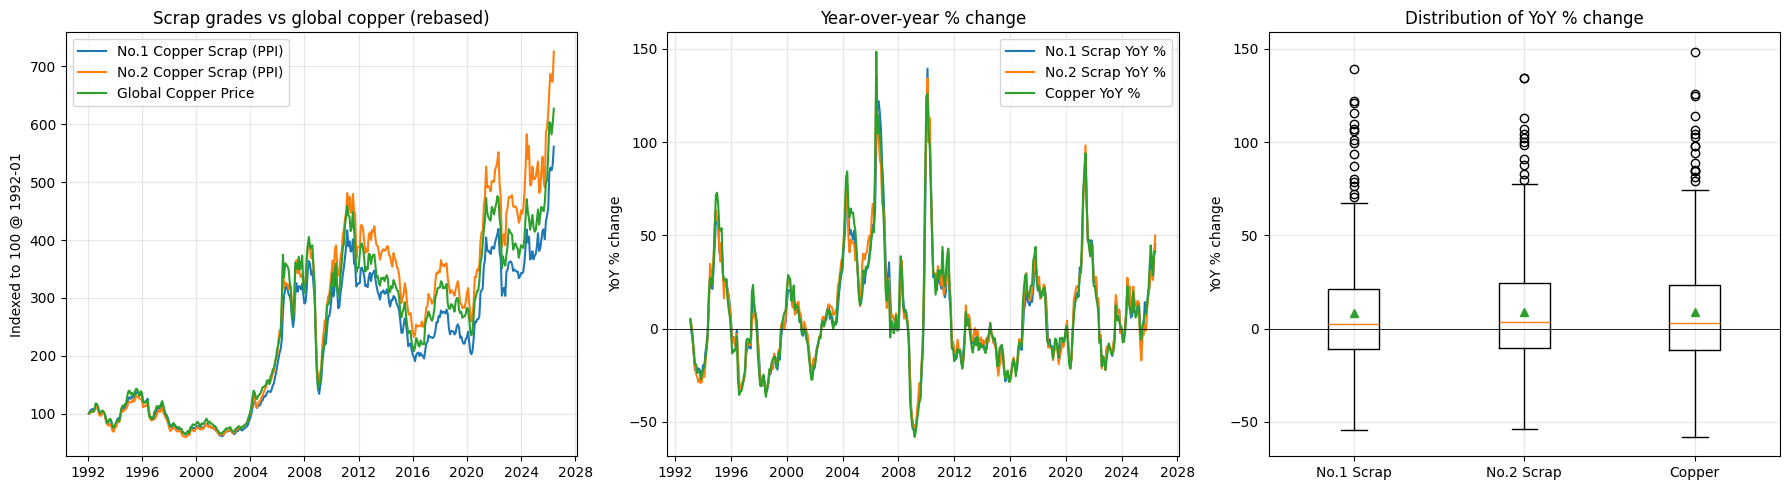

Correlations            monthly%   YoY%
No.1 scrap  vs copper      0.835    0.981
No.2 scrap  vs copper      0.839    0.983
No.1 scrap  vs No.2 scrap   0.893    0.984


In [28]:
core = df[["scrap_no1", "scrap_no2", "copper_global"]]
rebased = core / core.iloc[0] * 100
yoy = core.pct_change(12) * 100

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(rebased.index, rebased["scrap_no1"], label="No.1 Copper Scrap (PPI)")
ax1.plot(rebased.index, rebased["scrap_no2"], label="No.2 Copper Scrap (PPI)")
ax1.plot(rebased.index, rebased["copper_global"], label="Global Copper Price")
ax1.set_ylabel(f"Indexed to 100 @ {df.index[0]:%Y-%m}")
ax1.set_title("Scrap grades vs global copper (rebased)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(yoy.index, yoy["scrap_no1"], label="No.1 Scrap YoY %")
ax2.plot(yoy.index, yoy["scrap_no2"], label="No.2 Scrap YoY %")
ax2.plot(yoy.index, yoy["copper_global"], label="Copper YoY %")
ax2.axhline(0, color="k", lw=0.6)
ax2.set_ylabel("YoY % change")
ax2.set_title("Year-over-year % change")
ax2.legend()
ax2.grid(alpha=0.3)

labels = ["No.1 Scrap", "No.2 Scrap", "Copper"]
ax3.boxplot([yoy[c].dropna() for c in core.columns], labels=labels, showmeans=True)
ax3.axhline(0, color="k", lw=0.6)
ax3.set_ylabel("YoY % change")
ax3.set_title("Distribution of YoY % change")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

ret = core.pct_change()
pairs = [
    ("scrap_no1", "copper_global", "No.1 scrap  vs copper"),
    ("scrap_no2", "copper_global", "No.2 scrap  vs copper"),
    ("scrap_no1", "scrap_no2",     "No.1 scrap  vs No.2 scrap"),
]
print("Correlations            monthly%   YoY%")
for a, b, name in pairs:
    print(f"{name:24s} {ret[a].corr(ret[b]):7.3f}  {yoy[a].corr(yoy[b]):7.3f}")